# Transfer Learning Evaluation: v4.3 on Held-Out Species

Evaluates the trained **Hybrid v4.3** model (DNA/LTR/LINE + superfamily) on three held-out curated TE libraries that were **never seen during training**:

| Species | Code | Clade |
|---------|------|-------|
| Zebra finch (*Taeniopygia guttata*) | `bTaeGut` | Aves |
| Platypus (*Ornithorhynchus anatinus*) | `mOrnAna` | Monotremata |
| American alligator (*Alligator mississippiensis*) | `rAllMis` | Crocodylia |

**Visualisations produced**:
1. Bar chart: per-species class-level F1 (DNA / LTR / LINE)
2. Heatmap: per-superfamily F1 across species
3. Error analysis: which superfamilies fail per species
4. Class-level confusion matrices per species

In [1]:
# ============ Imports ============
import gc
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional
from collections import Counter
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score
)

import matplotlib.pyplot as plt
import seaborn as sns

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if hasattr(torch.backends, 'mps'):
    print(f"MPS available: {torch.backends.mps.is_available()}")

PyTorch version: 2.9.0
CUDA available: False
MPS available: True


In [2]:
# ============ Configuration ============
FASTA_PATH = "../../../data/vgp/all_vgp_tes.fa"
LABEL_PATH = "../../../data/vgp/20260120_features_sf"

# Benchmark genomes to exclude from training (avoid data leakage)
# These genomes are used for independent validation in mini_benchmark/
EXCLUDE_GENOMES = {'mOrnAna', 'bTaeGut', 'rAllMis'}

# Model hyperparameters
FIXED_LENGTH = 20000          # CNN canvas size
MIN_CLASS_COUNT = 100         # Minimum samples per superfamily
MAX_PER_SF = 3000             # Max samples per superfamily (subsample large classes)
LABEL_SMOOTHING = 0.1

# Top-level class configuration (replaces binary DNA+/None)
KEEP_CLASSES = ['DNA', 'LTR', 'LINE']  # Drop None, SINE, PLE, RC
CLASS_NAMES = KEEP_CLASSES             # 3-class head: DNA vs LTR vs LINE
N_CLASSES = len(CLASS_NAMES)

# K-mer GNN parameters
KMER_K = 7                   # K-mer size
KMER_DIM = 2048              # Hash dimension
KMER_WINDOW = 512            # Window size for k-mer features
KMER_STRIDE = 256            # Stride for sliding window
GNN_HIDDEN = 128             # GNN hidden dimension
GNN_LAYERS = 3               # Number of GNN layers

# CNN parameters
CNN_WIDTH = 128              # CNN channel width
MOTIF_KERNELS = (7, 15, 21)  # Multi-scale motif detection
CONTEXT_DILATIONS = (1, 2, 4, 8)  # Dilated convolutions
RC_FUSION_MODE = "late"      # "early" or "late" RC fusion

# Fusion parameters
FUSION_DIM = 256             # Attention fusion dimension
NUM_HEADS = 4                # Number of attention heads

# Training parameters
BATCH_SIZE = 16              # Smaller batch for dual-tower model
EPOCHS = 40 
LR = 1e-3
DROPOUT = 0.15

def resolve_device(requested=None):
    """Return the best available accelerator."""
    if requested is not None:
        return torch.device(requested)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = resolve_device()
print(f"Using device: {DEVICE}")


Using device: mps


In [3]:
# ============ FASTA and Label Loading ============

def read_fasta(path):
    """Read FASTA file and return headers and sequences."""
    headers, sequences = [], []
    h, buf = None, []
    
    with open(path, 'r') as f:
        for line in f:
            if not line:
                continue
            if line[0] == '>':
                if h is not None:
                    sequences.append(''.join(buf).upper())
                    buf = []
                h = line[1:].strip()
                headers.append(h)
            else:
                buf.append(line.strip())
        if h is not None:
            sequences.append(''.join(buf).upper())
    return headers, sequences


def load_multiclass_labels(label_path, keep_classes=('DNA', 'LTR', 'LINE')):
    """
    Load labels for multi-class hierarchical classification.
    
    Args:
        label_path: Path to label file (header<TAB>superfamily).
        keep_classes: Top-level classes to keep (e.g., DNA, LTR, LINE).
                      All others (None, SINE, PLE, RC) are dropped.
    
    Returns:
        label_dict: header -> tag (superfamily string)
        class_dict: header -> class_id (0=DNA, 1=LTR, 2=LINE based on order in keep_classes)
    """
    label_path = Path(label_path)
    class_to_id = {c: i for i, c in enumerate(keep_classes)}
    
    label_dict, class_dict = {}, {}
    superfamilies = Counter()
    skipped_classes = Counter()
    
    with label_path.open("r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            header = parts[0].lstrip('>')
            tag = parts[1]
            
            # Get top-level class from tag (e.g., "DNA/hAT" -> "DNA")
            top_class = tag.split('/')[0]
            
            # Only keep sequences from keep_classes
            if top_class in class_to_id:
                label_dict[header] = tag
                class_dict[header] = class_to_id[top_class]
                superfamilies[tag] += 1
            else:
                skipped_classes[tag] += 1
    
    print(f"Loaded {len(label_dict)} sequences (filtered to {keep_classes})")
    print(f"\\nSuperfamily distribution by class:")
    for cls in keep_classes:
        cls_tags = {t for t in superfamilies if t == cls or t.startswith(cls + "/")}
        cls_count = sum(superfamilies[t] for t in cls_tags)
        print(f"\\n  {cls} ({cls_count} total):")
        for tag, count in sorted(superfamilies.items(), key=lambda x: -x[1]):
            if tag in cls_tags:
                pct = 100 * count / len(label_dict)
                print(f"    ✓ {tag}: {count} ({pct:.1f}%)")
    
    if skipped_classes:
        print(f"\\nDropped classes:")
        for tag, count in sorted(skipped_classes.items(), key=lambda x: -x[1])[:10]:
            print(f"    ✗ {tag}: {count}")
        if len(skipped_classes) > 10:
            print(f"    ... and {len(skipped_classes) - 10} more")
    
    # Summary
    print(f"\\nClass distribution:")
    for cls, cls_id in class_to_id.items():
        n = sum(1 for v in class_dict.values() if v == cls_id)
        print(f"  {cls} (id={cls_id}): {n}")
    
    return label_dict, class_dict


def compute_class_weights(y_ids, n_classes, mode="inv_sqrt", eps=1e-6):
    """Compute class weights for imbalanced multi-class."""
    counts = np.bincount(np.asarray(y_ids, dtype=np.int64), minlength=n_classes).astype(np.float64)
    if mode == "none":
        w = np.ones(n_classes, dtype=np.float32)
    elif mode == "inv":
        w = 1.0 / (counts + eps)
    elif mode == "inv_sqrt":
        w = 1.0 / np.sqrt(counts + eps)
    else:
        raise ValueError(f"Unknown mode={mode}")
    w = w / (w.mean() + 1e-12)
    return w.astype(np.float32)

In [4]:
# ============ K-mer Feature Extraction ============

# ASCII -> {0,1,2,3,4} for A,C,G,T,other
_ASCII_MAP = np.full(256, 4, dtype=np.uint8)
for ch, val in [("A", 0), ("C", 1), ("G", 2), ("T", 3), ("a", 0), ("c", 1), ("g", 2), ("t", 3)]:
    _ASCII_MAP[ord(ch)] = val

_COMP = np.array([3, 2, 1, 0], dtype=np.uint8)  # A<->T, C<->G


def kmer_code_forward(arr4: np.ndarray) -> int:
    code = 0
    for v in arr4:
        code = (code << 2) | int(v)
    return code


def kmer_code_rc(arr4: np.ndarray) -> int:
    code = 0
    for v in arr4[::-1]:
        code = (code << 2) | int(_COMP[v])
    return code


def canonical_kmer_code(arr4: np.ndarray) -> int:
    c1 = kmer_code_forward(arr4)
    c2 = kmer_code_rc(arr4)
    return c1 if c1 < c2 else c2


def hash_u32(x: int, dim: int) -> int:
    z = (x * 0x9E3779B97F4A7C15) & 0xFFFFFFFFFFFFFFFF
    z ^= (z >> 33)
    z = (z * 0xC2B2AE3D27D4EB4F) & 0xFFFFFFFFFFFFFFFF
    z ^= (z >> 29)
    return int(z % dim)


@dataclass
class KmerWindowFeaturizer:
    """Extract k-mer frequency features from sliding windows."""
    k: int = 7
    dim: int = 2048
    window: int = 512
    stride: int = 256
    add_pos: bool = True
    l2_normalize: bool = True

    def featurize_sequence(self, seq: str) -> Tuple[np.ndarray, np.ndarray]:
        arr = _ASCII_MAP[np.frombuffer(seq.encode("ascii", "ignore"), dtype=np.uint8)]
        L = int(arr.size)
        
        if L == 0:
            X = np.zeros((1, self.dim + (1 if self.add_pos else 0)), dtype=np.float32)
            return X, np.array([0], dtype=np.int64)

        if L <= self.window:
            starts = np.array([0], dtype=np.int64)
        else:
            starts = np.arange(0, L - self.window + 1, self.stride, dtype=np.int64)
            if starts.size == 0:
                starts = np.array([0], dtype=np.int64)

        out_dim = self.dim + (1 if self.add_pos else 0)
        X = np.zeros((starts.size, out_dim), dtype=np.float32)

        for wi, st in enumerate(starts):
            en = min(st + self.window, L)
            sub = arr[st:en]
            counts = np.zeros(self.dim, dtype=np.float32)
            total = 0

            k = self.k
            if sub.size >= k:
                for i in range(0, sub.size - k + 1):
                    kmer = sub[i:i + k]
                    if np.any(kmer == 4):
                        continue
                    code = canonical_kmer_code(kmer)
                    j = hash_u32(code, self.dim)
                    counts[j] += 1.0
                    total += 1

            if total > 0:
                counts /= float(total)

            if self.l2_normalize:
                nrm = np.linalg.norm(counts)
                if nrm > 0:
                    counts /= nrm

            if self.add_pos:
                center = (st + en) / 2.0
                pos = center / max(1.0, float(L))
                X[wi, :-1] = counts
                X[wi, -1] = pos
            else:
                X[wi, :] = counts

        return X, starts


def build_chain_edge_index(n: int, undirected: bool = True, self_loops: bool = True) -> torch.Tensor:
    """Build edge index for a chain graph (windows connected sequentially)."""
    edges = []
    if n > 1:
        src = np.arange(n - 1, dtype=np.int64)
        dst = np.arange(1, n, dtype=np.int64)
        edges.append((src, dst))
        if undirected:
            edges.append((dst, src))
    if self_loops:
        idx = np.arange(n, dtype=np.int64)
        edges.append((idx, idx))
    if not edges:
        ei = np.zeros((2, 0), dtype=np.int64)
    else:
        s = np.concatenate([e[0] for e in edges])
        d = np.concatenate([e[1] for e in edges])
        ei = np.stack([s, d], axis=0)
    return torch.from_numpy(ei)

In [5]:
# ============ Encoding for CNN ============

# Mapping ACGT to 0-3, N to 4
ENCODE = np.full(256, 4, dtype=np.int64)
for ch, idx in zip(b"ACGTNacgtn", [0, 1, 2, 3, 4, 0, 1, 2, 3, 4]):
    ENCODE[ch] = idx

# Reverse complement: ACGTN -> TGCAN -> indices [3, 2, 1, 0, 4]
REV_COMP = torch.tensor([3, 2, 1, 0, 4], dtype=torch.long)


class HybridDataset(Dataset):
    """
    Dataset that provides both CNN (one-hot) and GNN (k-mer) features.
    
    For each sequence:
    - CNN: One-hot encoding placed randomly in fixed-length canvas
    - GNN: Pre-computed k-mer window features
    """
    def __init__(
        self,
        headers: List[str],
        sequences: List[str],
        binary_labels: np.ndarray,
        class_labels: np.ndarray,
        kmer_features: List[np.ndarray],  # Pre-computed k-mer features
        fixed_length: int = FIXED_LENGTH
    ):
        self.headers = list(headers)
        self.sequences = list(sequences)
        self.binary_labels = np.asarray(binary_labels, dtype=np.int64)
        self.class_labels = np.asarray(class_labels, dtype=np.int64)
        self.kmer_features = kmer_features
        self.fixed_length = fixed_length
        self.seq_lengths = np.array([len(s) for s in sequences], dtype=np.int64)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        seq_len = len(seq)

        # Encode sequence for CNN
        seq_bytes = seq.encode("ascii", "ignore")
        seq_idx = ENCODE[np.frombuffer(seq_bytes, dtype=np.uint8)]

        # Random placement in canvas
        max_start = max(0, self.fixed_length - seq_len)
        start_pos = np.random.randint(0, max_start + 1) if max_start > 0 else 0
        end_pos = start_pos + seq_len

        # K-mer features (pre-computed)
        kmer_feat = self.kmer_features[idx]  # (n_windows, kmer_dim+1)

        return (
            self.headers[idx],
            seq_idx,
            int(self.binary_labels[idx]),
            int(self.class_labels[idx]),
            start_pos,
            end_pos,
            seq_len,
            kmer_feat
        )


def collate_hybrid(batch, fixed_length=FIXED_LENGTH):
    """
    Collate function for hybrid model.
    
    Returns:
        headers: list of header strings
        X_cnn: (B, 5, fixed_length) one-hot for CNN
        mask: (B, fixed_length) padding mask
        Y_binary: (B,) binary labels
        Y_class: (B,) class labels
        x_gnn: (total_nodes, feat_dim) stacked node features
        edge_index: (2, total_edges) graph edges
        batch_vec: (total_nodes,) batch assignment
    """
    (headers, seq_idxs, binary_labels, class_labels, 
     starts, ends, lengths, kmer_feats) = zip(*batch)

    B = len(batch)
    
    # ---- CNN inputs ----
    X_cnn = torch.zeros((B, 5, fixed_length), dtype=torch.float32)
    mask = torch.zeros((B, fixed_length), dtype=torch.bool)

    for i, (seq_idx, start, end, seq_len) in enumerate(zip(seq_idxs, starts, ends, lengths)):
        actual_len = min(seq_len, fixed_length - start)
        if actual_len > 0:
            idx = torch.from_numpy(seq_idx[:actual_len].astype(np.int64))
            pos = torch.arange(actual_len, dtype=torch.long) + start
            X_cnn[i, idx, pos] = 1.0
            mask[i, start:start + actual_len] = (idx != 4)

    Y_binary = torch.tensor(binary_labels, dtype=torch.long)
    Y_class = torch.tensor(class_labels, dtype=torch.long)

    # ---- GNN inputs ----
    xs, eis, batch_vecs = [], [], []
    node_offset = 0

    for gi, kmer_feat in enumerate(kmer_feats):
        x = torch.from_numpy(kmer_feat).to(torch.float32)
        n = x.size(0)
        ei = build_chain_edge_index(n, undirected=True, self_loops=True)
        
        xs.append(x)
        eis.append(ei + node_offset)
        batch_vecs.append(torch.full((n,), gi, dtype=torch.int64))
        node_offset += n

    x_gnn = torch.cat(xs, dim=0)
    edge_index = torch.cat(eis, dim=1) if eis else torch.zeros((2, 0), dtype=torch.int64)
    batch_vec = torch.cat(batch_vecs, dim=0)

    return (
        list(headers), X_cnn, mask, Y_binary, Y_class,
        x_gnn, edge_index, batch_vec
    )

In [6]:
# ============ CNN Building Blocks ============

class ConvBlock(nn.Module):
    """Residual convolutional block with optional dilation."""
    def __init__(self, c_in, c_out, kernel_size=9, dilation=1, dropout=0.1):
        super().__init__()
        assert kernel_size % 2 == 1
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(c_in, c_out, kernel_size, padding=pad, dilation=dilation, bias=True)
        self.bn = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.proj = nn.Identity() if c_in == c_out else nn.Conv1d(c_in, c_out, 1)

    def forward(self, x):
        y = self.conv(x)
        y = F.gelu(self.bn(y))
        y = self.drop(y)
        return y + self.proj(x)


class MaskedMaxPool1d(nn.Module):
    """Max pooling that respects padding mask."""
    def __init__(self, kernel_size=2, stride=2):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride

    def forward(self, x, mask):
        if mask is not None:
            m = mask.unsqueeze(1).float()
            x = x * m + (~mask.unsqueeze(1)) * (-1e9)
        x_p = F.max_pool1d(x, self.kernel_size, self.stride)
        if mask is None:
            return x_p, None
        m_p = F.max_pool1d(mask.float().unsqueeze(1), self.kernel_size, self.stride).squeeze(1) > 0
        return x_p, m_p


def masked_avg_pool(z, mask):
    """Global average pooling respecting mask."""
    if mask is None:
        return z.mean(-1)
    m = mask.unsqueeze(1).float()
    return (z * m).sum(-1) / m.sum(-1).clamp_min(1.0)


class RCFirstConv1d(nn.Module):
    """RC-invariant first convolution (early fusion)."""
    def __init__(self, out_channels, kernel_size=15, dilation=1, bias=True, dropout=0.1):
        super().__init__()
        assert kernel_size % 2 == 1
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(5, out_channels, kernel_size, padding=pad, dilation=dilation, bias=bias)
        self.batch_norm = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        y1 = self.conv(x)
        x_rc = x.flip(-1).index_select(1, REV_COMP.to(x.device))
        y2 = self.conv(x_rc).flip(-1)
        y = torch.max(y1, y2)
        y = self.batch_norm(y)
        y = F.gelu(y)
        y = self.dropout(y)
        return y

In [7]:
# ============ CNN Tower ============

class CNNTower(nn.Module):
    """
    CNN tower for sequence motif detection.
    Produces a fixed-size embedding from one-hot encoded DNA sequence.
    """
    def __init__(
        self,
        width: int = 128,
        motif_kernels: Tuple[int, ...] = (7, 15, 21),
        context_kernel: int = 9,
        context_dilations: Tuple[int, ...] = (1, 2, 4, 8),
        dropout: float = 0.15,
        rc_mode: str = "late"
    ):
        super().__init__()
        self.rc_mode = rc_mode
        self.out_dim = width
        
        # Motif detection layers
        if rc_mode == "early":
            self.motif_convs = nn.ModuleList([
                RCFirstConv1d(width, kernel_size=k, dropout=dropout)
                for k in motif_kernels
            ])
        else:
            self.motif_convs = nn.ModuleList([
                nn.Sequential(
                    nn.Conv1d(5, width, kernel_size=k, padding=k // 2, bias=True),
                    nn.BatchNorm1d(width),
                    nn.GELU(),
                    nn.Dropout(dropout)
                )
                for k in motif_kernels
            ])
        
        # Mix layer
        in_ch = width * len(motif_kernels)
        self.mix = nn.Sequential(
            nn.Conv1d(in_ch, width, kernel_size=1, bias=True),
            nn.BatchNorm1d(width),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        # Context blocks with dilation
        self.context_blocks = nn.ModuleList([
            ConvBlock(width, width, kernel_size=context_kernel, dilation=d, dropout=dropout)
            for d in context_dilations
        ])
        self.pool = MaskedMaxPool1d(kernel_size=2, stride=2)

    @staticmethod
    def rc_transform(x, mask):
        """Apply reverse complement transformation."""
        x_rc = x.index_select(1, REV_COMP.to(x.device)).flip(-1)
        mask_rc = None if mask is None else mask.flip(-1)
        return x_rc, mask_rc

    def encode(self, x, mask):
        """Encode sequence through CNN layers."""
        feats = [conv(x) for conv in self.motif_convs]
        z = torch.cat(feats, dim=1)
        z = self.mix(z)
        
        m = mask
        for block in self.context_blocks:
            z = block(z)
            z, m = self.pool(z, m)
        
        return masked_avg_pool(z, m)  # (B, width)

    def forward(self, x, mask):
        """
        Forward pass with RC handling.
        Returns: (B, width) embedding
        """
        if self.rc_mode == "late":
            f = self.encode(x, mask)
            x_rc, mask_rc = self.rc_transform(x, mask)
            r = self.encode(x_rc, mask_rc)
            return 0.5 * (f + r)
        else:
            return self.encode(x, mask)

In [8]:
# ============ GNN Building Blocks ============

def scatter_mean(x: torch.Tensor, idx: torch.Tensor, dim_size: int) -> torch.Tensor:
    """Scatter mean for graph pooling."""
    out = torch.zeros((dim_size, x.size(1)), device=x.device, dtype=x.dtype)
    out.index_add_(0, idx, x)
    cnt = torch.bincount(idx, minlength=dim_size).clamp_min(1).to(x.device).to(x.dtype).unsqueeze(1)
    return out / cnt


class GraphSAGELayer(nn.Module):
    """GraphSAGE-style message passing layer."""
    def __init__(self, in_dim: int, out_dim: int, dropout: float = 0.1):
        super().__init__()
        self.lin_self = nn.Linear(in_dim, out_dim)
        self.lin_neigh = nn.Linear(in_dim, out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        src, dst = edge_index[0], edge_index[1]
        agg = torch.zeros_like(x)
        agg.index_add_(0, dst, x[src])
        deg = torch.bincount(dst, minlength=x.size(0)).clamp_min(1).to(x.device).to(x.dtype).unsqueeze(1)
        agg = agg / deg
        h = self.lin_self(x) + self.lin_neigh(agg)
        h = F.relu(h)
        return self.dropout(h)


class GNNTower(nn.Module):
    """
    GNN tower for k-mer composition analysis.
    Produces a fixed-size embedding from k-mer window features.
    """
    def __init__(
        self,
        in_dim: int,
        hidden: int = 128,
        n_layers: int = 3,
        dropout: float = 0.1
    ):
        super().__init__()
        self.out_dim = hidden
        
        layers = []
        d = in_dim
        for _ in range(n_layers):
            layers.append(GraphSAGELayer(d, hidden, dropout=dropout))
            d = hidden
        self.layers = nn.ModuleList(layers)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, batch_vec: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.
        Args:
            x: (N, in_dim) node features
            edge_index: (2, E) edges
            batch_vec: (N,) batch assignment
        Returns:
            (B, hidden) graph-level embeddings
        """
        for layer in self.layers:
            x = layer(x, edge_index)
        
        B = int(batch_vec.max().item()) + 1 if batch_vec.numel() else 0
        return scatter_mean(x, batch_vec, dim_size=B)

In [9]:
# ============ Cross-Modal Attention Fusion ============

class CrossModalAttentionFusion(nn.Module):
    """
    Fuses CNN and GNN embeddings using cross-modal attention.
    
    Features:
    - Projects both embeddings to a common fusion dimension
    - Self-attention across modalities
    - Learned gating for adaptive weighting
    """
    def __init__(
        self,
        cnn_dim: int = 128,
        gnn_dim: int = 128,
        fusion_dim: int = 256,
        num_heads: int = 4,
        dropout: float = 0.2
    ):
        super().__init__()
        self.fusion_dim = fusion_dim
        
        # Project both embeddings to fusion dimension
        self.cnn_proj = nn.Linear(cnn_dim, fusion_dim)
        self.gnn_proj = nn.Linear(gnn_dim, fusion_dim)
        
        # Layer norm before attention
        self.ln1 = nn.LayerNorm(fusion_dim)
        self.ln2 = nn.LayerNorm(fusion_dim)
        
        # Cross-modal attention
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=fusion_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        
        # Learned gating for adaptive fusion
        self.gate = nn.Sequential(
            nn.Linear(fusion_dim * 2, fusion_dim),
            nn.GELU(),
            nn.Linear(fusion_dim, 2),
            nn.Softmax(dim=-1)
        )
        
        # Output projection
        self.out_proj = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

    def forward(self, cnn_embed: torch.Tensor, gnn_embed: torch.Tensor):
        """
        Args:
            cnn_embed: (B, cnn_dim) from CNN tower
            gnn_embed: (B, gnn_dim) from GNN tower
        
        Returns:
            fused: (B, fusion_dim) fused embedding
            gate_weights: (B, 2) for interpretability [cnn_weight, gnn_weight]
        """
        # Project to fusion dimension
        c = self.cnn_proj(cnn_embed)  # (B, fusion_dim)
        g = self.gnn_proj(gnn_embed)  # (B, fusion_dim)
        
        # Layer norm
        c = self.ln1(c)
        g = self.ln2(g)
        
        # Stack as sequence: (B, 2, fusion_dim)
        combined = torch.stack([c, g], dim=1)
        
        # Self-attention across modalities
        attn_out, _ = self.cross_attn(combined, combined, combined)
        
        # Extract attended features
        c_attn = attn_out[:, 0]  # (B, fusion_dim)
        g_attn = attn_out[:, 1]  # (B, fusion_dim)
        
        # Learned gating
        gate_input = torch.cat([c_attn, g_attn], dim=-1)
        gate_weights = self.gate(gate_input)  # (B, 2)
        
        # Weighted fusion
        fused = gate_weights[:, 0:1] * c_attn + gate_weights[:, 1:2] * g_attn
        
        # Output projection
        fused = self.out_proj(fused)
        
        return fused, gate_weights

In [10]:
# ============ Hybrid TE Classifier V4 ============

class HybridTEClassifierV4(nn.Module):
    """
    Hybrid TE Classifier combining CNN and K-mer GNN towers.
    
    Architecture:
    1. CNN Tower: Captures local sequence motifs with RC-invariance
    2. GNN Tower: Captures k-mer compositional patterns via message passing
    3. Attention Fusion: Combines both embeddings with learned weighting
    4. Hierarchical Heads: Top-level class (DNA/LTR/LINE) and superfamily
    """
    def __init__(
        self,
        num_classes: int,           # Top-level classes (DNA, LTR, LINE)
        num_superfamilies: int,
        # CNN params
        cnn_width: int = 128,
        motif_kernels: Tuple[int, ...] = (7, 15, 21),
        context_dilations: Tuple[int, ...] = (1, 2, 4, 8),
        rc_mode: str = "late",
        # GNN params
        gnn_in_dim: int = 2049,  # kmer_dim + 1 (position)
        gnn_hidden: int = 128,
        gnn_layers: int = 3,
        # Fusion params
        fusion_dim: int = 256,
        num_heads: int = 4,
        dropout: float = 0.15
    ):
        super().__init__()
        self.num_classes = num_classes
        self.num_superfamilies = num_superfamilies
        
        # ---- CNN Tower ----
        self.cnn_tower = CNNTower(
            width=cnn_width,
            motif_kernels=motif_kernels,
            context_dilations=context_dilations,
            dropout=dropout,
            rc_mode=rc_mode
        )
        
        # ---- GNN Tower ----
        self.gnn_tower = GNNTower(
            in_dim=gnn_in_dim,
            hidden=gnn_hidden,
            n_layers=gnn_layers,
            dropout=dropout
        )
        
        # ---- Attention Fusion ----
        self.fusion = CrossModalAttentionFusion(
            cnn_dim=cnn_width,
            gnn_dim=gnn_hidden,
            fusion_dim=fusion_dim,
            num_heads=num_heads,
            dropout=dropout
        )
        
        # ---- Top-Level Class Head (DNA vs LTR vs LINE) ----
        self.class_head = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
        
        # ---- Superfamily Classification Head ----
        self.superfamily_head = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_superfamilies)
        )

    def forward(
        self,
        x_cnn: torch.Tensor,
        mask: torch.Tensor,
        x_gnn: torch.Tensor,
        edge_index: torch.Tensor,
        batch_vec: torch.Tensor
    ):
        """
        Forward pass.
        
        Args:
            x_cnn: (B, 5, L) one-hot DNA for CNN
            mask: (B, L) padding mask
            x_gnn: (N_nodes, gnn_in_dim) k-mer features
            edge_index: (2, E) graph edges
            batch_vec: (N_nodes,) batch assignment
        
        Returns:
            class_logits: (B, num_classes) DNA vs LTR vs LINE
            superfamily_logits: (B, num_superfamilies)
            gate_weights: (B, 2) fusion weights [CNN, GNN]
        """
        # Get embeddings from both towers
        cnn_embed = self.cnn_tower(x_cnn, mask)  # (B, cnn_width)
        gnn_embed = self.gnn_tower(x_gnn, edge_index, batch_vec)  # (B, gnn_hidden)
        
        # Fuse with attention
        fused, gate_weights = self.fusion(cnn_embed, gnn_embed)  # (B, fusion_dim)
        
        # Classification heads
        class_logits = self.class_head(fused)
        superfamily_logits = self.superfamily_head(fused)
        
        return class_logits, superfamily_logits, gate_weights

## 1. Load v4.3 Checkpoint

Loads the saved results (superfamily names, class names) and rebuilds the model from the best training checkpoint.

In [11]:
import glob as glob_module
from functools import partial

# ---- Load saved results (superfamily mapping, class names) ----
RESULTS_PATH = "./results_v4.3.pt"
results = torch.load(RESULTS_PATH, map_location="cpu", weights_only=False)

class_names        = results['class_names']
superfamily_names  = results['superfamily_names']
superfamily_to_id  = results['superfamily_to_id']
id_to_superfamily  = {v: k for k, v in superfamily_to_id.items()}
class_to_id        = {c: i for i, c in enumerate(class_names)}
num_classes        = len(class_names)
num_superfamilies  = len(superfamily_names)

print(f"Classes ({num_classes}): {class_names}")
print(f"Superfamilies: {num_superfamilies}")

# ---- Auto-detect best checkpoint ----
if 'best_epoch' in results:
    _best_ep = results['best_epoch']
else:
    _ckpts = sorted(glob_module.glob("hybrid_v4.3_epoch*.pt"))
    _best_ep = int(_ckpts[-1].split('epoch')[1].split('.')[0]) if _ckpts else 40
CHECKPOINT_PATH = f"./hybrid_v4.3_epoch{_best_ep}.pt"
print(f"Using checkpoint: {CHECKPOINT_PATH}")

# ---- Rebuild model ----
_featurizer = KmerWindowFeaturizer(k=KMER_K, dim=KMER_DIM, window=KMER_WINDOW, stride=KMER_STRIDE)

model = HybridTEClassifierV4(
    num_classes=num_classes,
    num_superfamilies=num_superfamilies,
    cnn_width=CNN_WIDTH,
    motif_kernels=MOTIF_KERNELS,
    context_dilations=CONTEXT_DILATIONS,
    rc_mode=RC_FUSION_MODE,
    gnn_in_dim=KMER_DIM + 1,
    gnn_hidden=GNN_HIDDEN,
    gnn_layers=GNN_LAYERS,
    fusion_dim=FUSION_DIM,
    num_heads=NUM_HEADS,
    dropout=DROPOUT,
).to(DEVICE)

ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"Model loaded — epoch {ckpt.get('epoch', '?')}")


Classes (3): ['DNA', 'LTR', 'LINE']
Superfamilies: 23
Using checkpoint: ./hybrid_v4.3_epoch40.pt
Model loaded — epoch 40


## 2. Parse Benchmark FASTA Files & Run Inference

Header format: `>Name#CLASS/SUPERFAMILY @Taxon [S:score]`  
Only sequences with top-level class in {DNA, LTR, LINE} are evaluated.  
For superfamily evaluation, labels are matched to the model's known superfamilies (exact match → parent-level fallback → unmapped).

In [12]:
from collections import Counter, defaultdict
from sklearn.metrics import f1_score, classification_report, confusion_matrix

BENCHMARK_DIR = "../../../data/mini_benchmark"
BENCHMARK_FILES = {
    'bTaeGut (Zebra finch)':  f"{BENCHMARK_DIR}/bTaeGut/taeniopygia_guttata_lib.fa",
    'mOrnAna (Platypus)':     f"{BENCHMARK_DIR}/mOrnAna/platypus_curated_lib.fa",
    'rAllMis (Alligator)':    f"{BENCHMARK_DIR}/rAllMis/Aligator_mississippiensis_lib.fa",
}
BATCH_SIZE_BENCH = 32


def parse_benchmark_fasta(path, superfamily_to_id, class_names):
    """Parse a curated TE library FASTA. Returns matched entries with SF/class labels."""
    keep_classes = set(class_names)
    _class_to_id = {c: i for i, c in enumerate(class_names)}

    def find_sf_id(tag):
        if tag in superfamily_to_id:
            return superfamily_to_id[tag], tag, 'exact'
        if '/' in tag:
            parts = tag.split('/')
            base_class, sf_part = parts[0], parts[1]
            if '-' in sf_part:
                parent = f"{base_class}/{sf_part.split('-')[0]}"
                if parent in superfamily_to_id:
                    return superfamily_to_id[parent], parent, 'parent'
            if base_class in superfamily_to_id:
                return superfamily_to_id[base_class], base_class, 'class_only'
        return None, None, 'unmapped'

    headers, sequences = [], []
    h, buf = None, []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if h:
                    headers.append(h)
                    sequences.append(''.join(buf).upper())
                h, buf = line[1:], []
            else:
                buf.append(line)
        if h:
            headers.append(h)
            sequences.append(''.join(buf).upper())

    matched = []
    stats = {'total': len(headers), 'wrong_class': 0, 'no_hash': 0,
             'exact': 0, 'parent': 0, 'class_only': 0, 'unmapped': 0}
    unmapped_labels = Counter()

    for hdr, seq in zip(headers, sequences):
        if '#' not in hdr:
            stats['no_hash'] += 1
            continue
        tag_part = hdr.split('#', 1)[1]
        tag = tag_part.split()[0].rstrip('?')
        top_class = tag.split('/')[0]
        if top_class not in keep_classes:
            stats['wrong_class'] += 1
            unmapped_labels[tag_part.split()[0]] += 1
            continue
        sf_id, mapped_to, match_type = find_sf_id(tag)
        if sf_id is None:
            stats['unmapped'] += 1
            unmapped_labels[tag] += 1
            continue
        stats[match_type] += 1
        matched.append({
            'header': hdr,
            'sequence': seq,
            'cls_id': _class_to_id[top_class],
            'sf_id': sf_id,
            'original_tag': tag,
            'mapped_to': mapped_to,
            'match_type': match_type,
        })

    return matched, stats, unmapped_labels


def run_benchmark_inference(matched_entries, model, featurizer, device, batch_size=32):
    """Run inference; returns (cls_true, cls_pred, sf_true, sf_pred, confidences)."""
    seqs    = [e['sequence'] for e in matched_entries]
    sf_ids  = [e['sf_id']   for e in matched_entries]
    cls_ids = [e['cls_id']  for e in matched_entries]
    hdrs    = [e['header']  for e in matched_entries]

    kmer_feats = [featurizer.featurize_sequence(s)[0] for s in seqs]

    ds = HybridDataset(
        headers=hdrs, sequences=seqs,
        binary_labels=sf_ids, class_labels=cls_ids,
        kmer_features=kmer_feats, fixed_length=FIXED_LENGTH,
    )
    loader = DataLoader(
        ds, batch_size=batch_size, shuffle=False,
        collate_fn=partial(collate_hybrid, fixed_length=FIXED_LENGTH),
        num_workers=0,
    )

    all_cls_true, all_cls_pred = [], []
    all_sf_true,  all_sf_pred  = [], []
    all_conf = []

    with torch.no_grad():
        for batch in loader:
            _, X_cnn, mask, Y_sf, Y_cls, x_gnn, edge_index, batch_vec = batch
            X_cnn      = X_cnn.to(device)
            mask       = mask.to(device)
            x_gnn      = x_gnn.to(device)
            edge_index = edge_index.to(device)
            batch_vec  = batch_vec.to(device)

            cls_logits, sf_logits, _ = model(X_cnn, mask, x_gnn, edge_index, batch_vec)
            probs = torch.softmax(cls_logits, dim=-1)
            all_cls_true.extend(Y_cls.tolist())
            all_cls_pred.extend(cls_logits.argmax(1).cpu().tolist())
            all_sf_true.extend(Y_sf.tolist())
            all_sf_pred.extend(sf_logits.argmax(1).cpu().tolist())
            all_conf.extend(probs.max(1).values.cpu().tolist())

    return all_cls_true, all_cls_pred, all_sf_true, all_sf_pred, all_conf


# ---- Run evaluation per genome ----
all_genome_results = {}

for genome_name, fasta_path in sorted(BENCHMARK_FILES.items()):
    print(f"\n{'='*60}")
    print(f"  {genome_name}")
    print(f"{'='*60}")

    matched, stats, unmapped = parse_benchmark_fasta(fasta_path, superfamily_to_id, class_names)

    print(f"  Total sequences    : {stats['total']}")
    print(f"  Evaluable (matched): {len(matched)}")
    print(f"    Exact SF match   : {stats['exact']}")
    print(f"    Parent fallback  : {stats['parent']}")
    print(f"    Class-only       : {stats['class_only']}")
    print(f"    Unmapped         : {stats['unmapped']}")
    print(f"    Wrong class      : {stats['wrong_class']}")

    if not matched:
        print("  Warning: No evaluable sequences.")
        continue

    cls_true, cls_pred, sf_true, sf_pred, conf = run_benchmark_inference(
        matched, model, _featurizer, DEVICE, batch_size=BATCH_SIZE_BENCH
    )

    cls_acc = sum(t == p for t, p in zip(cls_true, cls_pred)) / len(cls_true)
    cls_f1  = f1_score(cls_true, cls_pred, average='macro', zero_division=0)
    sf_acc  = sum(t == p for t, p in zip(sf_true, sf_pred)) / len(sf_true)
    sf_f1   = f1_score(sf_true, sf_pred, average='macro', zero_division=0)

    print(f"  Class  accuracy={cls_acc:.3f}  macro-F1={cls_f1:.3f}")
    print(f"  SF     accuracy={sf_acc:.3f}  macro-F1={sf_f1:.3f}")

    all_genome_results[genome_name] = {
        'matched': len(matched),
        'cls_true': cls_true, 'cls_pred': cls_pred,
        'sf_true':  sf_true,  'sf_pred':  sf_pred,
        'conf': conf,
        'cls_acc': cls_acc, 'cls_f1': cls_f1,
        'sf_acc':  sf_acc,  'sf_f1':  sf_f1,
        'entries': matched,
    }

print("\nBenchmark inference complete.")



  bTaeGut (Zebra finch)
  Total sequences    : 543
  Evaluable (matched): 415
    Exact SF match   : 174
    Parent fallback  : 10
    Class-only       : 231
    Unmapped         : 1
    Wrong class      : 127
  Class  accuracy=0.335  macro-F1=0.414
  SF     accuracy=0.188  macro-F1=0.130

  mOrnAna (Platypus)
  Total sequences    : 380
  Evaluable (matched): 206
    Exact SF match   : 126
    Parent fallback  : 22
    Class-only       : 58
    Unmapped         : 2
    Wrong class      : 172
  Class  accuracy=0.752  macro-F1=0.689
  SF     accuracy=0.422  macro-F1=0.196

  rAllMis (Alligator)
  Total sequences    : 1196
  Evaluable (matched): 1003
    Exact SF match   : 626
    Parent fallback  : 229
    Class-only       : 148
    Unmapped         : 31
    Wrong class      : 162
  Class  accuracy=0.607  macro-F1=0.586
  SF     accuracy=0.229  macro-F1=0.190

Benchmark inference complete.


## 3. Visualisation 1: Per-Species Class-Level Accuracy (DNA / LTR / LINE)

Left panel: per-class F1 broken down by species.  
Right panel: overall class accuracy, class F1, SF accuracy, SF F1 per species.

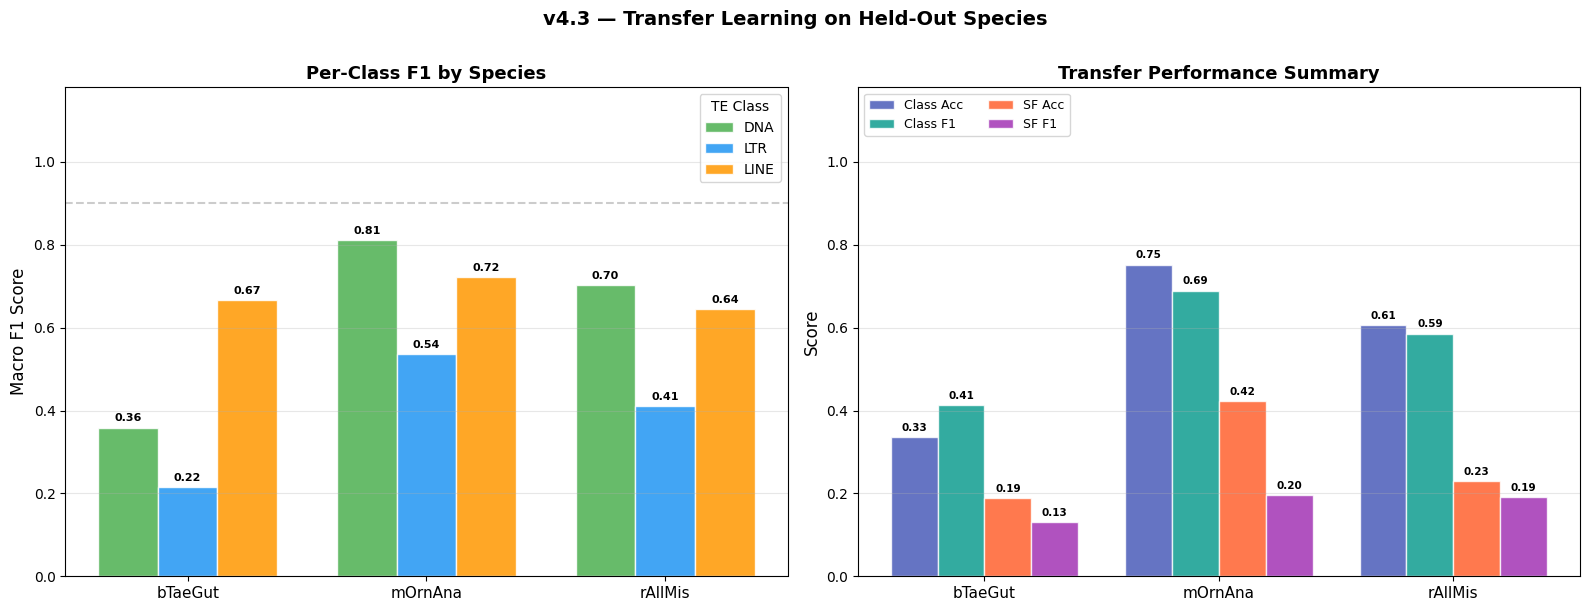

Saved: transfer_class_accuracy.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np

genome_labels = list(all_genome_results.keys())
n_genomes = len(genome_labels)
class_colors = {'DNA': '#4CAF50', 'LTR': '#2196F3', 'LINE': '#FF9800'}

# ---- Per-class F1 per genome ----
per_class_f1 = {cls: [] for cls in class_names}

for gn in genome_labels:
    r = all_genome_results[gn]
    report = classification_report(
        r['cls_true'], r['cls_pred'],
        labels=list(range(len(class_names))),
        target_names=class_names,
        output_dict=True, zero_division=0
    )
    for cls in class_names:
        per_class_f1[cls].append(report[cls]['f1-score'])

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: per-class F1 grouped by genome
ax = axes[0]
x = np.arange(n_genomes)
w = 0.25
for ci, cls in enumerate(class_names):
    ax.bar(x + ci * w, per_class_f1[cls], w,
           label=cls, color=class_colors[cls], alpha=0.85, edgecolor='white')
    for xi, v in zip(x + ci * w, per_class_f1[cls]):
        ax.text(xi, v + 0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + w)
ax.set_xticklabels([g.split('(')[0].strip() for g in genome_labels], fontsize=11)
ax.set_ylim(0, 1.18)
ax.set_ylabel("Macro F1 Score", fontsize=12)
ax.set_title("Per-Class F1 by Species", fontsize=13, fontweight='bold')
ax.legend(title="TE Class", fontsize=10)
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.4)
ax.grid(axis='y', alpha=0.3)

# RIGHT: overall metrics
ax2 = axes[1]
metrics_labels = ['Class Acc', 'Class F1', 'SF Acc', 'SF F1']
metric_keys    = ['cls_acc', 'cls_f1', 'sf_acc', 'sf_f1']
bar_colors     = ['#3F51B5', '#009688', '#FF5722', '#9C27B0']
x2 = np.arange(n_genomes)
w2 = 0.20

for mi, (mk, ml, bc) in enumerate(zip(metric_keys, metrics_labels, bar_colors)):
    vals = [all_genome_results[g][mk] for g in genome_labels]
    ax2.bar(x2 + mi * w2, vals, w2, label=ml, color=bc, alpha=0.8, edgecolor='white')
    for xi, v in zip(x2 + mi * w2, vals):
        ax2.text(xi, v + 0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax2.set_xticks(x2 + 1.5 * w2)
ax2.set_xticklabels([g.split('(')[0].strip() for g in genome_labels], fontsize=11)
ax2.set_ylim(0, 1.18)
ax2.set_ylabel("Score", fontsize=12)
ax2.set_title("Transfer Performance Summary", fontsize=13, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9, ncol=2)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle("v4.3 — Transfer Learning on Held-Out Species", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("transfer_class_accuracy.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: transfer_class_accuracy.png")


## 4. Visualisation 2: Per-Superfamily F1 Heatmap Across Species

Rows = superfamilies present in ≥1 benchmark species (≥3 true samples).  
Columns = species. Grey = not present in that species.

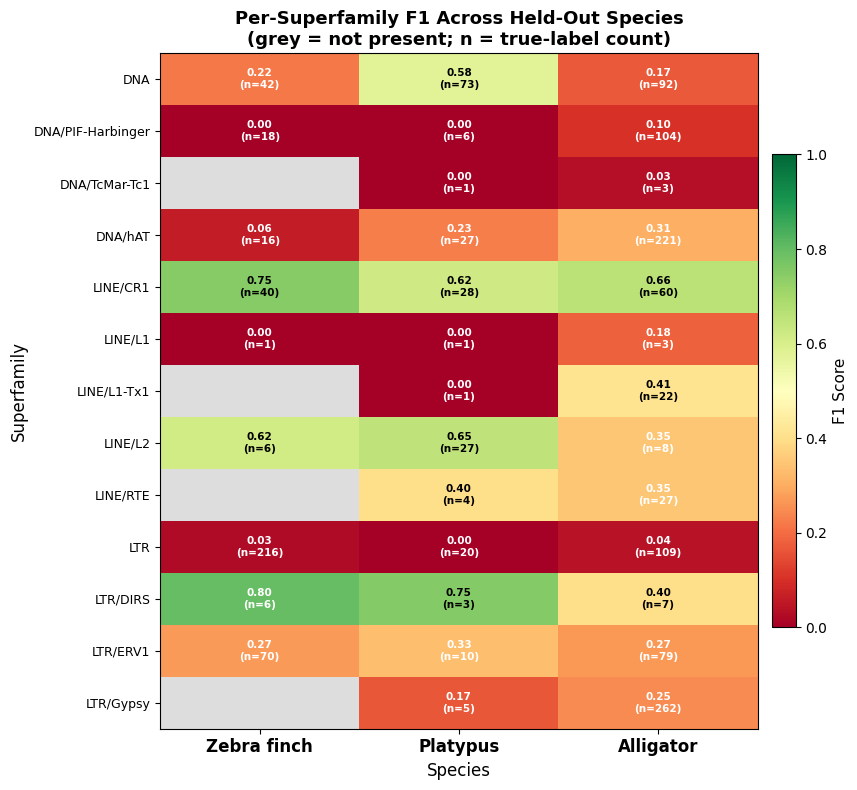

Saved: transfer_sf_heatmap.png


In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score
from collections import defaultdict

# ---- Compute per-superfamily F1 per genome ----
def per_sf_f1_dict(sf_true, sf_pred):
    scores = {}
    for sf_id in set(sf_true):
        y_t = [1 if v == sf_id else 0 for v in sf_true]
        y_p = [1 if v == sf_id else 0 for v in sf_pred]
        if sum(y_t) == 0:
            continue
        scores[sf_id] = f1_score(y_t, y_p, zero_division=0)
    return scores

genome_sf_f1 = {}
for gn, r in all_genome_results.items():
    genome_sf_f1[gn] = per_sf_f1_dict(r['sf_true'], r['sf_pred'])

# ---- SF support per genome ----
sf_support = defaultdict(lambda: defaultdict(int))
for gn, r in all_genome_results.items():
    for sf_id in r['sf_true']:
        sf_support[sf_id][gn] += 1

# Keep SFs with >=3 true samples in at least one genome
active_sf_ids = sorted(
    [sf_id for sf_id, counts in sf_support.items() if max(counts.values()) >= 3],
    key=lambda i: id_to_superfamily[i]
)

genome_names = list(all_genome_results.keys())
short_labels = [g.split('(')[1].rstrip(')') if '(' in g else g for g in genome_names]
sf_labels_hm = [id_to_superfamily[i] for i in active_sf_ids]

matrix = np.full((len(active_sf_ids), len(genome_names)), np.nan)
for gi, gn in enumerate(genome_names):
    for ri, sf_id in enumerate(active_sf_ids):
        if sf_id in genome_sf_f1[gn]:
            matrix[ri, gi] = genome_sf_f1[gn][sf_id]

# ---- Plot ----
fig_h = max(8, len(active_sf_ids) * 0.38)
fig, ax = plt.subplots(figsize=(max(8, len(genome_names) * 3), fig_h))

cmap = plt.cm.RdYlGn.copy()
cmap.set_bad(color='#DDDDDD')
masked = np.ma.masked_invalid(matrix)
im = ax.imshow(masked, cmap=cmap, vmin=0, vmax=1, aspect='auto', interpolation='nearest')

for ri in range(len(active_sf_ids)):
    for ci in range(len(genome_names)):
        val = matrix[ri, ci]
        if not np.isnan(val):
            sup = sf_support[active_sf_ids[ri]][genome_names[ci]]
            color = 'white' if (val < 0.35 or val > 0.75) else 'black'
            ax.text(ci, ri, f"{val:.2f}\n(n={sup})",
                    ha='center', va='center', fontsize=7.5, color=color, fontweight='bold')

ax.set_xticks(range(len(genome_names)))
ax.set_xticklabels(short_labels, fontsize=12, fontweight='bold')
ax.set_yticks(range(len(active_sf_ids)))
ax.set_yticklabels(sf_labels_hm, fontsize=9)
ax.set_xlabel("Species", fontsize=12)
ax.set_ylabel("Superfamily", fontsize=12)
ax.set_title(
    "Per-Superfamily F1 Across Held-Out Species\n(grey = not present; n = true-label count)",
    fontsize=13, fontweight='bold'
)
cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label("F1 Score", fontsize=11)
plt.tight_layout()
plt.savefig("transfer_sf_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: transfer_sf_heatmap.png")


## 5. Visualisation 3: Error Analysis — Which Superfamilies Fail Per Species

Horizontal bar chart: top-12 superfamilies with highest SF-level error rate per species.  
Red bar = SF-level error rate; orange bar = class-level error rate.

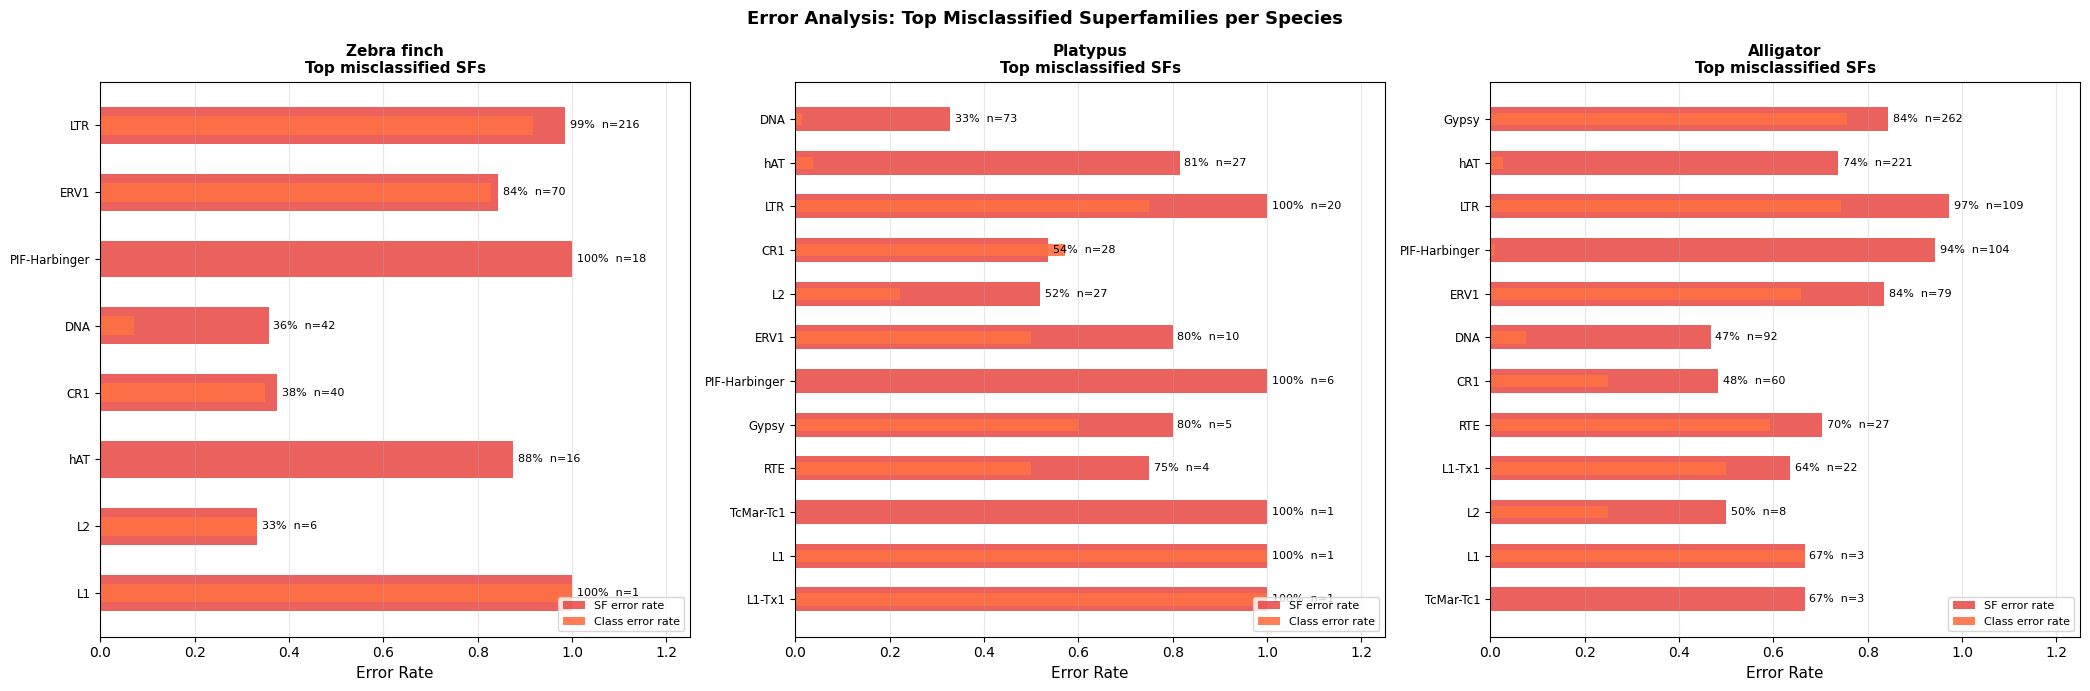

Saved: transfer_error_analysis.png


In [15]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

def get_top_errors(cls_true, cls_pred, sf_true, sf_pred, sf_names, cls_names, top_n=12):
    sf_err_counter = Counter()
    sf_true_counter = Counter(sf_true)
    for t_sf, p_sf in zip(sf_true, sf_pred):
        if t_sf != p_sf:
            sf_err_counter[t_sf] += 1
    top_sf = [sf_id for sf_id, _ in sf_err_counter.most_common(top_n)]
    errors = []
    for sf_id in top_sf:
        total = sf_true_counter[sf_id]
        cls_err = sum(1 for t_sf, t_cls, p_cls in zip(sf_true, cls_true, cls_pred)
                      if t_sf == sf_id and t_cls != p_cls)
        top_pred = Counter(p_sf for t_sf, p_sf in zip(sf_true, sf_pred)
                           if t_sf == sf_id and t_sf != p_sf).most_common(3)
        errors.append({
            'sf_id': sf_id,
            'sf_name': sf_names[sf_id],
            'total': total,
            'sf_error_rate': sf_err_counter[sf_id] / max(1, total),
            'cls_error_rate': cls_err / max(1, total),
            'top_predicted': top_pred,
        })
    return errors

n_g = len(all_genome_results)
fig, axes = plt.subplots(1, n_g, figsize=(7 * n_g, 7), sharey=False)
if n_g == 1:
    axes = [axes]

for ax, gn in zip(axes, all_genome_results.keys()):
    r = all_genome_results[gn]
    errors = get_top_errors(r['cls_true'], r['cls_pred'],
                            r['sf_true'], r['sf_pred'],
                            superfamily_names, class_names, top_n=12)
    if not errors:
        ax.text(0.5, 0.5, 'No errors', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(gn)
        continue

    # Shorten SF names for readability
    sf_disp = [e['sf_name'].replace('DNA/', '').replace('LTR/', '').replace('LINE/', '')
               for e in errors]
    sf_err  = [e['sf_error_rate'] for e in errors]
    cls_err = [e['cls_error_rate'] for e in errors]
    sups    = [e['total'] for e in errors]

    y = np.arange(len(errors))
    ax.barh(y, sf_err,  height=0.55, color='#E53935', alpha=0.8, label='SF error rate')
    ax.barh(y, cls_err, height=0.28, color='#FF7043', alpha=0.9, label='Class error rate')

    for yi, (se, sup) in enumerate(zip(sf_err, sups)):
        ax.text(max(se + 0.01, 0.03), yi, f"{se:.0%}  n={sup}",
                va='center', fontsize=8)

    ax.set_yticks(y)
    ax.set_yticklabels(sf_disp, fontsize=8.5)
    ax.invert_yaxis()
    ax.set_xlim(0, 1.25)
    ax.set_xlabel("Error Rate", fontsize=11)
    short = gn.split('(')[1].rstrip(')') if '(' in gn else gn
    ax.set_title(f"{short}\nTop misclassified SFs", fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle("Error Analysis: Top Misclassified Superfamilies per Species",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("transfer_error_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: transfer_error_analysis.png")


## 6. Visualisation 4: Class-Level Confusion Matrices per Species

Row-normalised confusion matrices for the top-level DNA / LTR / LINE classification.

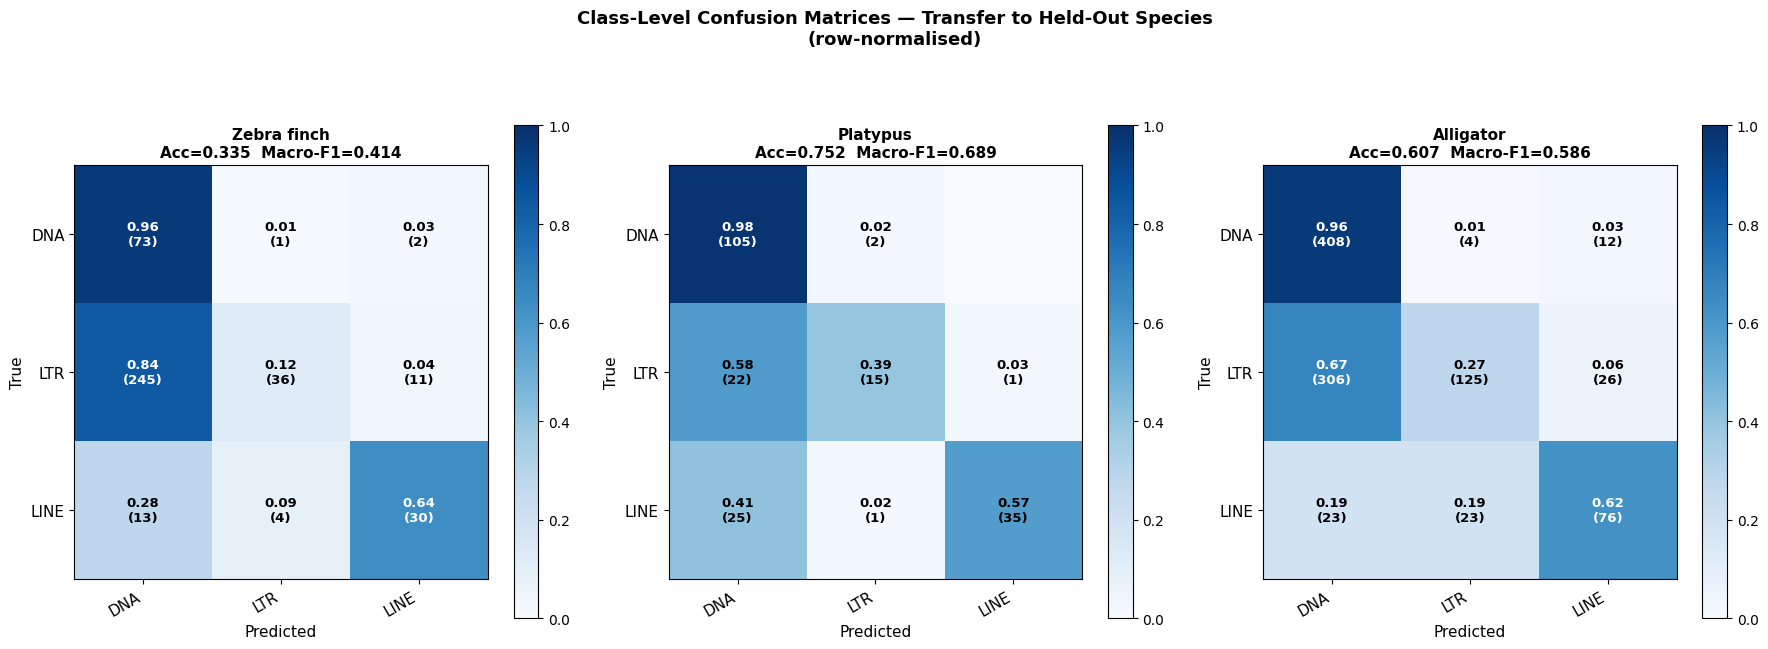

Saved: transfer_confusion_matrices.png


In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

n_g = len(all_genome_results)
fig, axes = plt.subplots(1, n_g, figsize=(6 * n_g, 7))
if n_g == 1:
    axes = [axes]

for ax, gn in zip(axes, all_genome_results.keys()):
    r = all_genome_results[gn]
    cm = confusion_matrix(r['cls_true'], r['cls_pred'],
                          labels=list(range(len(class_names))))
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm  = np.where(row_sums > 0, cm / row_sums, 0.0)

    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1, interpolation='nearest')
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=30, ha='right', fontsize=11)
    ax.set_yticks(range(len(class_names)))
    ax.set_yticklabels(class_names, fontsize=11)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True", fontsize=11)
    short = gn.split('(')[1].rstrip(')') if '(' in gn else gn
    ax.set_title(f"{short}\nAcc={r['cls_acc']:.3f}  Macro-F1={r['cls_f1']:.3f}",
                 fontsize=11, fontweight='bold')

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            cnt = cm[i, j]
            val = cm_norm[i, j]
            if cnt > 0:
                color = 'white' if val > 0.6 else 'black'
                ax.text(j, i, f"{val:.2f}\n({cnt})",
                        ha='center', va='center', fontsize=9.5,
                        color=color, fontweight='bold')

    plt.colorbar(im, ax=ax, shrink=0.8)

plt.subplots_adjust(wspace=0.4)
plt.suptitle(
    "Class-Level Confusion Matrices — Transfer to Held-Out Species\n(row-normalised)",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig("transfer_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: transfer_confusion_matrices.png")


## 7. Copy Figures to Thesis Folder

In [17]:
import shutil, os

THESIS_FIGURES = "../../../../thesis/figures/new_figures"
os.makedirs(THESIS_FIGURES, exist_ok=True)

for fname in [
    "transfer_class_accuracy.png",
    "transfer_sf_heatmap.png",
    "transfer_error_analysis.png",
    "transfer_confusion_matrices.png",
]:
    if os.path.exists(fname):
        dest = os.path.join(THESIS_FIGURES, fname)
        shutil.copy(fname, dest)
        print(f"Copied {fname} -> {dest}")
    else:
        print(f"Warning: {fname} not found — run the visualisation cells first.")


Copied transfer_class_accuracy.png -> ../../../../thesis/figures/new_figures/transfer_class_accuracy.png
Copied transfer_sf_heatmap.png -> ../../../../thesis/figures/new_figures/transfer_sf_heatmap.png
Copied transfer_error_analysis.png -> ../../../../thesis/figures/new_figures/transfer_error_analysis.png
Copied transfer_confusion_matrices.png -> ../../../../thesis/figures/new_figures/transfer_confusion_matrices.png
